# DESeq2 with new reference genome
# Phase 1 vs. Phase 1

focusing on pairwise comparisons involving oysters that experienced only **one** phase 1 (one exposure)

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)
library(vegan)
library(pheatmap)
library(RColorBrewer)
library(ggrepel)

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [3]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts <- counts %>%
select(-Gene_ID, -Length)

head(counts)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### meta data

In [4]:
# create df with col names from counts matrix
meta <- as.data.frame(colnames(counts))

colnames(meta) <- 'Sample'

# Separate into columns
meta <- meta %>%
   # Keep original SampleID
  mutate(OGSample = Sample) %>%
  # Split by '_'
  separate(Sample, into = c("Phase1", "Phase2", "Tag"), sep = "_") %>%
  mutate(
    Phase1_Treatment = substr(Phase1, 1, 1),
    Phase1_TankRep    = as.numeric(substr(Phase1, 2, nchar(Phase1))),
    Phase2_Treatment = gsub("[0-9]", "", Phase2),
    Phase2_TankRep       = as.numeric(gsub("[A-Za-z]", "", Phase2))
  ) %>%
  select(OGSample, Phase1_Treatment, Phase1_TankRep, Phase2_Treatment, Phase2_TankRep, Tag)

colnames(meta)[1] <- 'Sample'

head(meta)

,Sample,Phase1_Treatment,Phase1_TankRep,Phase2_Treatment,Phase2_TankRep,Tag
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
1,B1_B1_O01,B,1,B,1,O01
2,B1_Nu_O03,B,1,Nu,NA,O03
3,B1_W5_O50,B,1,W,5,O50
4,B2_B5_O51,B,2,B,5,O51
5,B2_C4_O40,B,2,C,4,O40
6,B2_Nu_O12,B,2,Nu,NA,O12


In [5]:
# adding treatment info
meta2 <- meta %>%
mutate(
    ## phase 1 treatments
    # overall
    Phase1_treatment = case_when(
        Phase1_Treatment == 'B' ~ 'both',
        Phase1_Treatment == 'H' ~ 'hypoxic',
        Phase1_Treatment == 'W' ~ 'warm',
        Phase1_Treatment == 'C' ~ 'control',
    TRUE ~ NA_character_),
    
    # temp
    Phase1_temp = case_when(
        Phase1_Treatment == 'B' ~ 'warm',
        Phase1_Treatment == 'H' ~ 'ambient',
        Phase1_Treatment == 'W' ~ 'warm',
        Phase1_Treatment == 'C' ~ 'ambient',
    TRUE ~ NA_character_),

    # dissolved oxygen
    Phase1_DO = case_when(
        Phase1_Treatment == 'B' ~ 'hypoxic',
        Phase1_Treatment == 'H' ~ 'hypoxic',
        Phase1_Treatment == 'W' ~ 'normoxic',
        Phase1_Treatment == 'C' ~ 'normoxic',
    TRUE ~ NA_character_),
    
    ## phase 2 treatments
    # overall
    Phase2_treatment = case_when(
        Phase2_Treatment == 'B' ~ 'both',
        Phase2_Treatment == 'H' ~ 'hypoxic',
        Phase2_Treatment == 'W' ~ 'warm',
        Phase2_Treatment == 'C' ~ 'control',
    TRUE ~ NA_character_),
    
    # temp
    Phase2_temp = case_when(
        Phase2_Treatment == 'B' ~ 'warm',
        Phase2_Treatment == 'H' ~ 'ambient',
        Phase2_Treatment == 'W' ~ 'warm',
        Phase2_Treatment == 'C' ~ 'ambient',
    TRUE ~ NA_character_),

    # dissolved oxygen
    Phase2_DO = case_when(
        Phase2_Treatment == 'B' ~ 'hypoxic',
        Phase2_Treatment == 'H' ~ 'hypoxic',
        Phase2_Treatment == 'W' ~ 'normoxic',
        Phase2_Treatment == 'C' ~ 'normoxic',
    TRUE ~ NA_character_)) %>%
select(Sample, Phase1_treatment, Phase1_temp, Phase1_DO, Phase1_TankRep, Phase2_treatment, Phase2_temp, Phase2_DO, Phase2_TankRep)

head(meta2)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


In [6]:
#write.csv(meta2, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/sample_metaData.csv', row.names=FALSE)

for this analysis, only looking at Phase 1 samples, so pulling those out

In [7]:
# if skipped above code:
meta2 <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')

In [8]:
# selecting only phase 1 sample
p1_meta <- meta2 %>%
filter(grepl("Nu", Sample)) %>%
filter(Sample != 'B3_Nu_O24') # this sample failed all QC steps, removing from analysis

# setting samples as rownames and deleting col from df
rownames(p1_meta) <- p1_meta$Sample
p1_meta <- p1_meta[, !colnames(p1_meta) %in% "Sample"]

p1_meta

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA
C1_Nu_W05,control,ambient,normoxic,1,NA,NA,NA,NA
C2_Nu_W15,control,ambient,normoxic,2,NA,NA,NA,NA
C3_Nu_W21,control,ambient,normoxic,3,NA,NA,NA,NA


In [9]:
# pulling out only phase 1 counts
p1_counts <- counts[,colnames(counts) %in% rownames(p1_meta)]
head(p1_counts)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2649,3974,2721,2246,2606,2804,2840,2829,2376,3580,⋯,2518,2269,3011,3027,3384,2316,2342,3478,2734,2374
LOC144621269,580,20011,11469,21,86,9642,2179,2944,4120,3621,⋯,7163,2405,217,35998,11679,2489,3926,11926,2,4034
LOC111120925,4,18,27,2,8,22,339,350,269,7,⋯,301,15,238,167,9,284,6,7,0,11
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [10]:
# setting the same order for counts matrix and meta data
p1_counts <- p1_counts[,rownames(p1_meta)]
all(rownames(p1_meta) == colnames(p1_counts))

[1] TRUE

## 2. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [11]:
# overall phase 1 treatment
p1_meta$Phase1_treatment <- factor(p1_meta$Phase1_treatment,
                                   levels = c('control', 'both', 'hypoxic', 'warm'))

In [12]:
# phase 1 tempature
p1_meta$Phase1_temp <- factor(p1_meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

In [13]:
# phase 1 DO
p1_meta$Phase1_DO <- factor(p1_meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

### phase 1 overall treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [14]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = p1_counts,
                              colData = p1_meta,
                              design = ~ Phase1_treatment)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

class: DESeqDataSet 
dim: 33903 23 
metadata(1): version
assays(1): counts
rownames(33903): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(8): Phase1_treatment Phase1_temp ... Phase2_DO
  Phase2_TankRep

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"                           "Phase1_treatment_both_vs_control"   
[3] "Phase1_treatment_hypoxic_vs_control" "Phase1_treatment_warm_vs_control"

33,903 genes to start

### pre-filter genes

In [15]:
# filter genes with inconsistent/low reads 
dds$group <- factor(dds$Phase1_treatment)

keep <- apply(counts(dds), # raw counts matrix
              1, # apply across rows - for each row/gene, apply this function: 
              function(x) {
  any(tapply(x, dds$group, # split counts for this gene by treatment combo
             function(g) sum(g >= 5) >= 3)) # does this treatment combo have at least 6 samples with counts of 10 or more?
             # any = is at least one group true?
})
dds_filtered <- dds[keep, ]


In [16]:
dds_filtered

class: DESeqDataSet 
dim: 25196 23 
metadata(1): version
assays(4): counts mu H cooks
rownames(25196): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(30): baseMean baseVar ... deviance maxCooks
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(10): Phase1_treatment Phase1_temp ... sizeFactor group

22343 genes after filtering

In [17]:
25196/33903
# kept ~75% of genes

[1] 0.7431791

#### run DESeq again

In [18]:
# run DESeq on the filtered dds object
dds_filtered <- DESeq(dds_filtered)

# run vst on new dds object
vst_mat <- assay(vst(dds_filtered, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [20]:
write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1_vst.csv')

### diagnostic tests

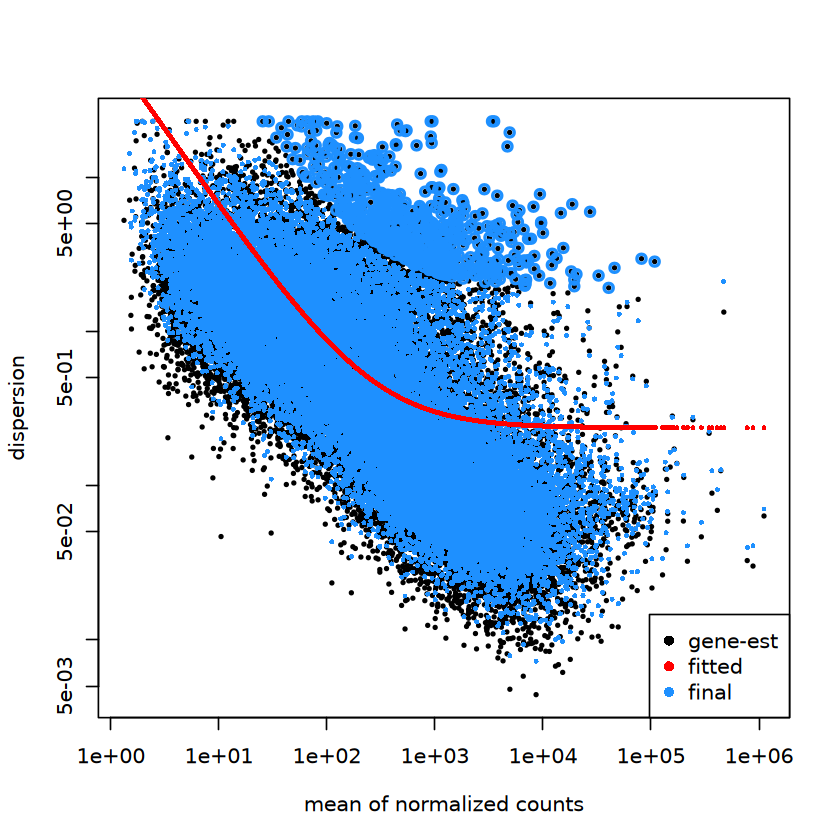

In [21]:
plotDispEsts(dds_filtered)

## nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [79]:
# normalization & transformation
vsd <- vst(dds_filtered, blind = FALSE)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.0000,172.0676,163.7663,148.2427,140.8442,156.1078,151.4854,162.5843,148.6235,143.7828,⋯,181.3153,148.5412,145.3274,199.1984,159.3238,154.6428,140.9241,156.3878,132.3680,148.5760
B2_Nu_O12,172.0676,0.0000,144.1658,193.4136,183.1232,140.4477,161.6368,164.4364,157.6985,143.4970,⋯,153.0460,149.1555,186.7158,146.7718,151.2684,158.9952,157.5580,145.8091,177.7005,146.2685
B4_Nu_O32,163.7663,144.1658,0.0000,174.2239,168.0534,148.4859,149.5726,147.2499,144.6350,144.8047,⋯,156.7922,108.2964,170.6913,149.2250,145.8398,156.0325,160.8244,139.6110,176.7033,141.5935
B5_Nu_O36,148.2427,193.4136,174.2239,0.0000,140.6526,180.9066,159.6940,161.9214,154.0008,167.7287,⋯,193.9648,159.2193,146.1800,208.9611,164.3245,175.9368,178.9654,172.1511,162.0573,163.2247
B6_Nu_O47,140.8442,183.1232,168.0534,140.6526,0.0000,170.3497,158.5765,151.2281,149.7721,156.1622,⋯,176.7102,149.0343,141.3860,204.7333,151.7577,171.0803,166.5323,150.0178,151.5072,151.8489
C1_Nu_W01,156.1078,140.4477,148.4859,180.9066,170.3497,0.0000,149.9222,157.3227,150.6997,133.5558,⋯,155.9097,147.0431,175.0169,159.7486,138.6484,150.4885,151.0790,140.5181,162.7350,140.9570


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor,group
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<fct>
B1_Nu_O03,57.95982,-34.939589,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324,both
B2_Nu_O12,-61.96924,-34.671208,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462,both
B4_Nu_O32,-34.28842,-1.585018,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377,both
B5_Nu_O36,79.76763,16.991191,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641,both
B6_Nu_O47,67.33204,1.352514,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226,both
C1_Nu_W01,-34.36848,-40.760884,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061,control


#### temp and DO

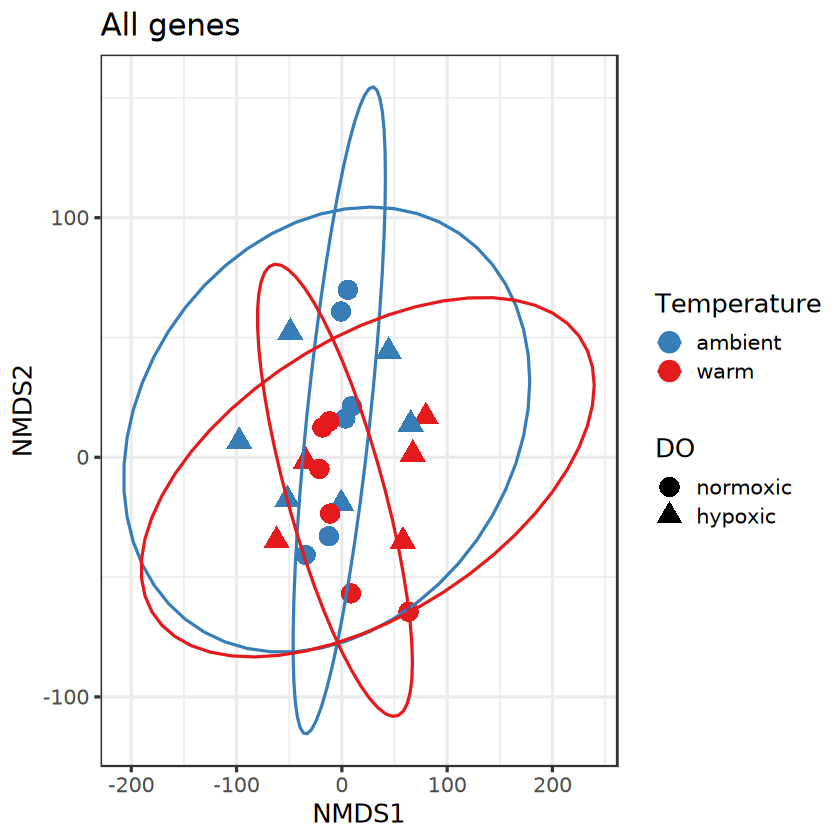

In [83]:
sample_name <- rownames(mds)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
stat_ellipse() + 
scale_color_brewer(palette = 'Set1', direction = -1) +
theme_bw(base_size = 15) +
labs(x = 'NMDS1',
     y = 'NMDS2',
     title = 'All genes',
     col = 'Temperature',
     shape = 'DO') 

nmds.plot

There doesn't appear to be any strong patterns of gene expression among the different phase 1 treatments

but the warm treatment looks less disperse than ambient treatment

There are some samples that appear to be "paired" - they're right next to each other - and so there's a concern that they may be from the same tank and therefore there's a tank effect on GE. Below, I'm going to plot the sample names to check this out:

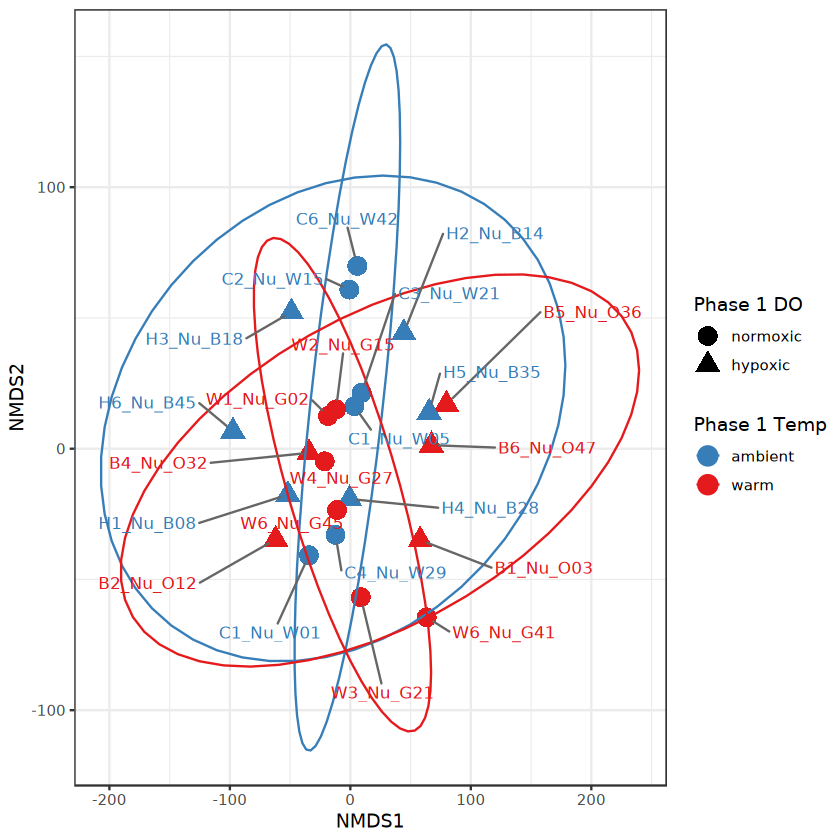

In [36]:
sample_name <- rownames(mds)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
  geom_point(size = 5) +
  stat_ellipse() +
  scale_color_brewer(palette = "Set1", direction = -1) +
  theme_bw() +
  labs(
    x = "NMDS1",
    y = "NMDS2",
    col = "Phase 1 Temp",
    shape = "Phase 1 DO"
  ) +
  geom_text_repel(
  aes(label = sample_name),
  size = 3.5,
  box.padding = 1,
  point.padding = 0.5,
  force = 2,
  segment.color = "grey40",
  segment.size = 0.5,
  max.overlaps = Inf
)

nmds.plot

good news! the samples next to each other are from different tanks - so there's not a tank effect!

There are only 2 treatments that have samples from the same tank replicate: warm and control (and they each only have 2 samples from the same tank)

For the rest, all samples are from different tanks (one from each of the 6 replicate tanks)

now, I'm going to plot the same NMDS as above but showing only one variable at a time

#### just temp

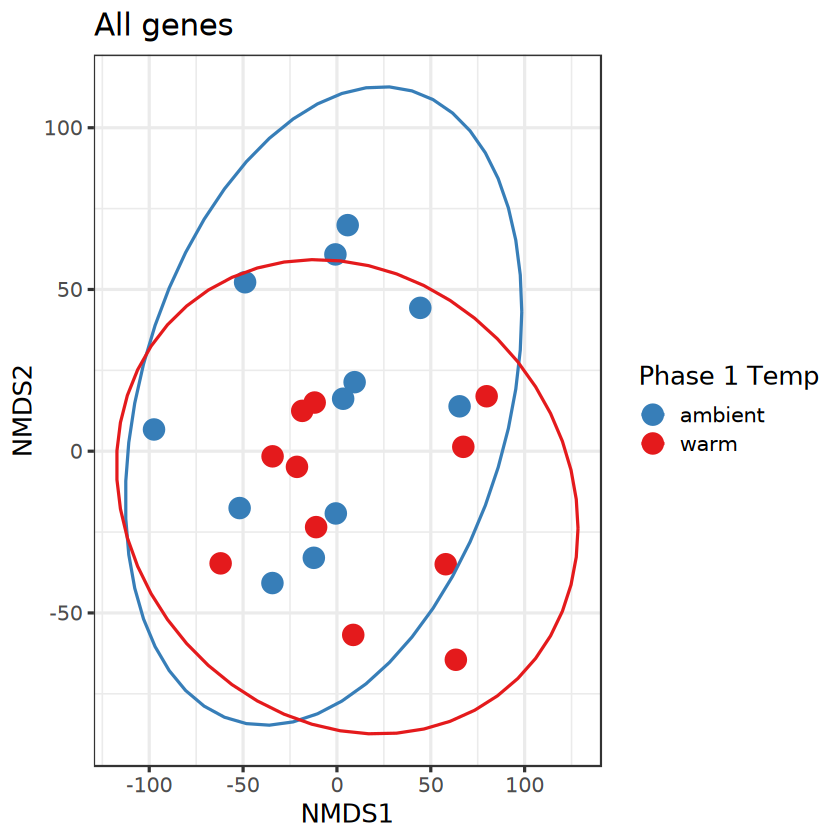

In [86]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp)) +
geom_point(size = 5) +
stat_ellipse() + 
scale_color_brewer(palette = 'Set1', direction = -1) +
theme_bw(base_size = 15) +
labs(x = 'NMDS1',
     y = 'NMDS2',
     col = 'Phase 1 Temp',
    title = 'All genes')

nmds.plot

#### just DO

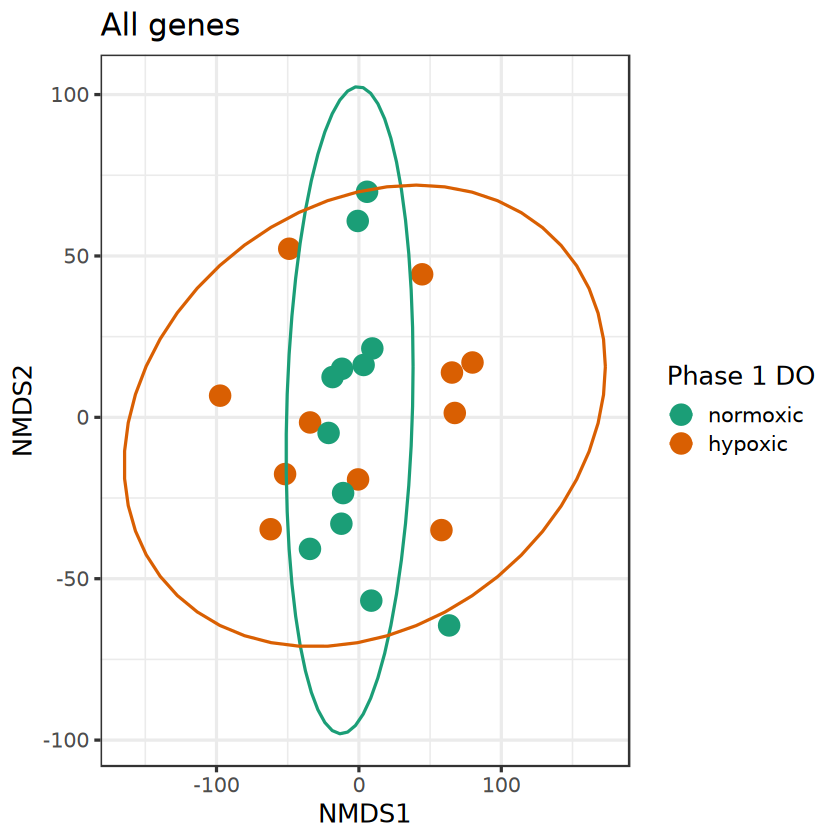

In [87]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_DO)) +
geom_point(size = 5) +
stat_ellipse() + 
scale_color_brewer(palette = 'Dark2') +
theme_bw(base_size = 15) +
labs(x = 'NMDS1',
     y = 'NMDS2',
     col = 'Phase 1 DO',
    title = 'All genes')

nmds.plot

## permANOVA

In [30]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO, data = p1_meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,15171.49,0.05589905,1.2294576,0.142
Phase1_DO,1,11628.32,0.04284430,0.9423281,0.517
Phase1_temp:Phase1_DO,1,10149.18,0.03739443,0.8224623,0.794
Residual,19,234459.79,0.86386223,NA,NA
Total,22,271408.77,1.00000000,NA,NA


permANOVA confirms that there isn't any statistically significant differences in gene expression patterns among phase 1 treatments 

## heatmap

In [30]:
# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 172.0676 163.7663 148.2427 140.8442 156.1078 151.4854

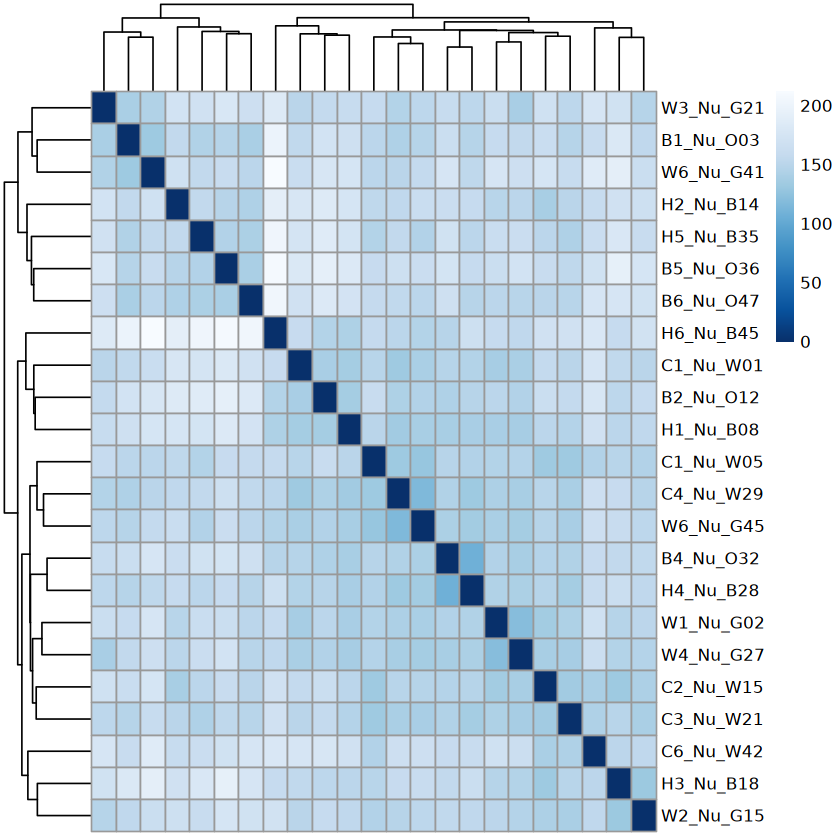

In [31]:
sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

### comparisons vs. control
applying `ashr` lfc shrinkage estimator - DESeq docs recommend `apeglm` but cannot use that for comparisons below so I want everything to be consistent

In [32]:
resultsNames(dds_filtered)

[1] "Intercept"                           "Phase1_treatment_both_vs_control"   
[3] "Phase1_treatment_hypoxic_vs_control" "Phase1_treatment_warm_vs_control"

#### warm vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 54, 0.21%
LFC < 0 (down)     : 75, 0.3%
outliers [1]       : 261, 1%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment warm vs control 
Wald test p-value: Phase1 treatment warm vs control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  2772.766     0.00388526 0.0531620 0.78621234  0.985438
LOC144621269  6797.381     0.00380193 0.1046955 0.66121266  0.978833
LOC111120925   191.443    -0.15664648 0.6482279 0.00954929  0.380979
LOC144621283   932.054     0.00691118 0.0572034 0.63313047  0.974590
LOC144621276 12350.889     0.01483559 0.0673080 0.34063104  0.908091
LOC111115920   213.339    -0.00322904 0.0658101 0.80154684  0.987493

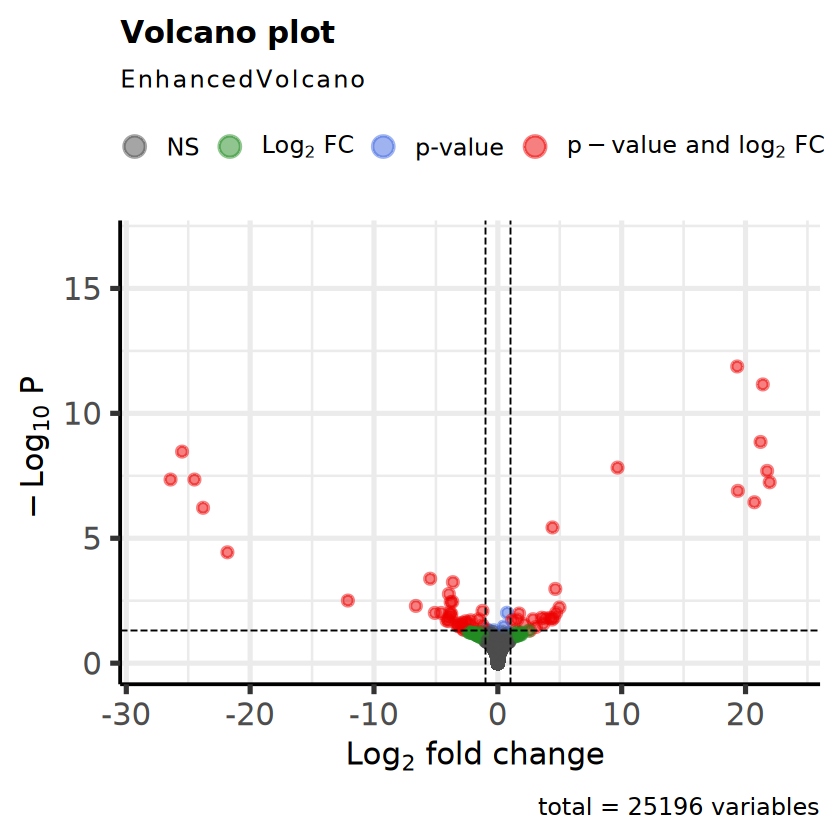

In [58]:
# phase 1 warm vs. control
res.warmLFC <- lfcShrink(dds_filtered, 
                         contrast = c('Phase1_treatment', 'warm', 'control'), 
                         type = 'ashr')

summary(res.warmLFC)

EnhancedVolcano(res.warmLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.warmLFC)

In [59]:
write.csv(as.data.frame(res.warmLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_cont.csv')

#### hypoxic vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 34, 0.13%
LFC < 0 (down)     : 24, 0.095%
outliers [1]       : 261, 1%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment hypoxic vs control 
Wald test p-value: Phase1 treatment hypoxic vs control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  2772.766     0.00805632 0.0413073  0.349542  0.972834
LOC144621269  6797.381     0.00657404 0.1090845  0.139642  0.928004
LOC111120925   191.443    -0.00674354 0.1106457  0.135048  0.928004
LOC144621283   932.054    -0.01123526 0.0426901  0.161982  0.942206
LOC144621276 12350.889     0.00504380 0.0415322  0.485809  0.987386
LOC111115920   213.339     0.00176373 0.0421061  0.739785  0.989992

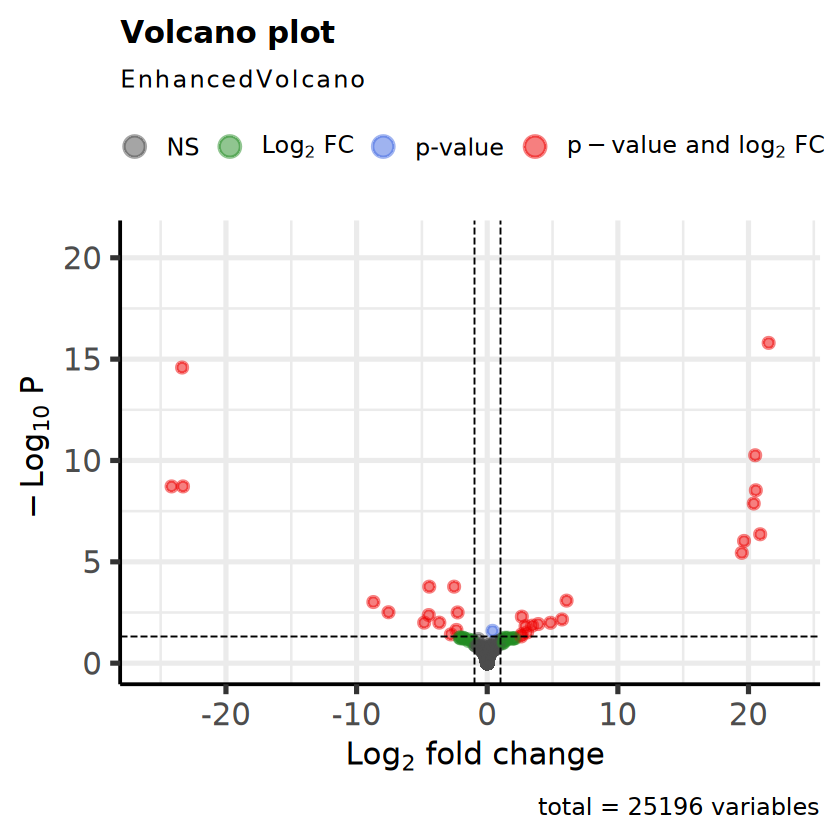

In [60]:
# phase 1 hypoxic vs. control
res.hypoxicLFC <- lfcShrink(dds_filtered, 
                            contrast = c('Phase1_treatment', 'hypoxic', 'control'),
                            type = 'ashr')

summary(res.hypoxicLFC)

EnhancedVolcano(res.hypoxicLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.hypoxicLFC)

In [61]:
write.csv(as.data.frame(res.hypoxicLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_cont.csv')

#### both vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 97, 0.38%
LFC < 0 (down)     : 235, 0.93%
outliers [1]       : 261, 1%
low counts [2]     : 489, 1.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment both vs control 
Wald test p-value: Phase1 treatment both vs control 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE      pvalue       padj
             <numeric>      <numeric> <numeric>   <numeric>  <numeric>
LOC144621260  2772.766     0.00067618 0.0222836 7.78713e-01 0.99674425
LOC144621269  6797.381     0.00430872 0.1099699 5.81377e-01 0.99206937
LOC111120925   191.443    -4.89646529 1.4092474 8.35454e-06 0.00358307
LOC144621283   932.054     0.00117828 0.0237116 6.19783e-01 0.99231593
LOC144621276 12350.889     0.00122661 0.0248093 5.97619e-01 0.99206937
LOC111115920   213.339     0.06763248 0.2503781 6.16003e-03 0.23488707

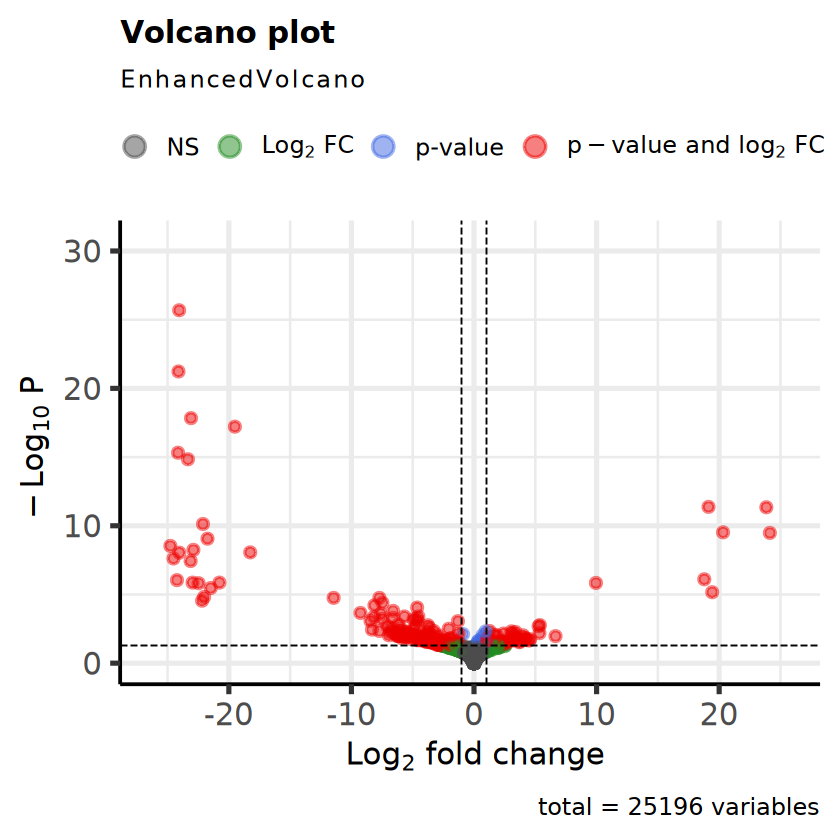

In [62]:
# phase 1 both vs. control
res.bothLFC <- lfcShrink(dds_filtered, 
                         contrast = c('Phase1_treatment', 'both', 'control'), 
                         type = 'ashr')

summary(res.bothLFC)

EnhancedVolcano(res.bothLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.bothLFC)

In [63]:
write.csv(as.data.frame(res.bothLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.both_v_cont.csv')

### other comparisons
(outside of just doing treatment vs. control)

using `ashr` for lfc shrinkage estimator (same as above)

#### warm vs. hypoxic

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 58, 0.23%
LFC < 0 (down)     : 37, 0.15%
outliers [1]       : 261, 1%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment hypoxic vs warm 
Wald test p-value: Phase1_treatment hypoxic vs warm 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE    pvalue      padj
             <numeric>      <numeric> <numeric> <numeric> <numeric>
LOC144621260  2772.766      0.0503310  0.121653 0.5065504  0.868457
LOC144621269  6797.381      0.0291376  0.192327 0.2988568  0.762442
LOC111120925   191.443      0.0310271  0.194652 0.2720993  0.742604
LOC144621283   932.054     -0.1464334  0.138156 0.0607734  0.499912
LOC144621276 12350.889     -0.0184418  0.130419 0.7980213  0.956523
LOC111115920   213.339      0.0366938  0.145892 0.5598569  0.886174

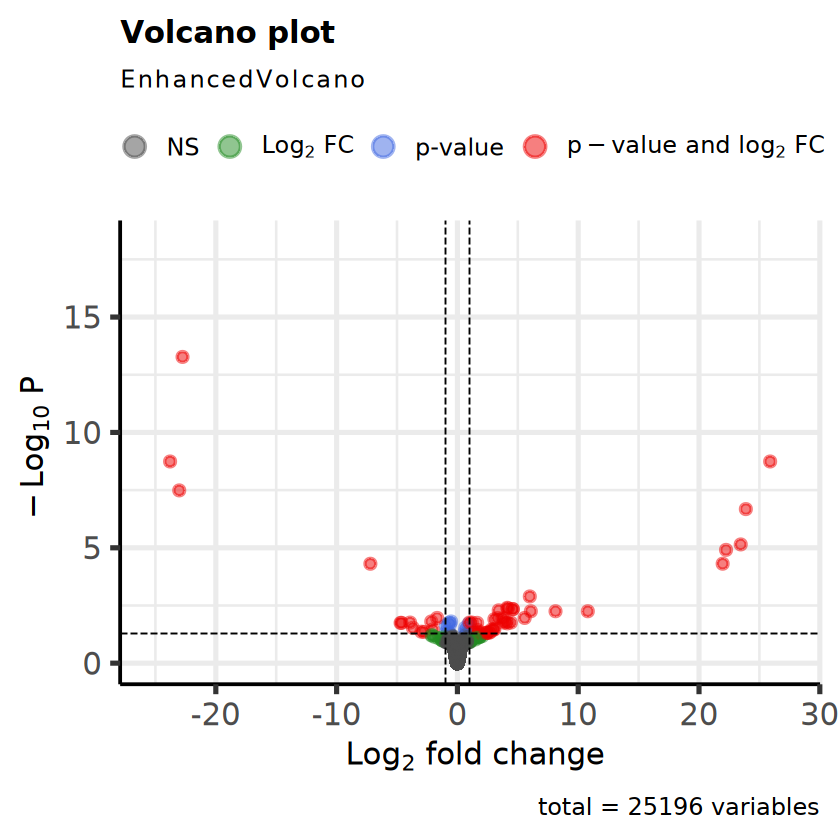

In [64]:
res.w.h <- lfcShrink(dds_filtered, 
                     contrast= c('Phase1_treatment', 'hypoxic', 'warm'), # warm is the "control"
                     type = 'ashr')

summary(res.w.h)

EnhancedVolcano(res.w.h,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.w.h)

In [65]:
write.csv(res.w.h, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_warm.csv')

#### warm vs. both

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 78, 0.31%
LFC < 0 (down)     : 68, 0.27%
outliers [1]       : 261, 1%
low counts [2]     : 1462, 5.8%
(mean count < 8)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment warm vs both 
Wald test p-value: Phase1_treatment warm vs both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange     lfcSE     pvalue      padj
             <numeric>      <numeric> <numeric>  <numeric> <numeric>
LOC144621260  2772.766    -0.00097376 0.0940134 0.98215404  0.998296
LOC144621269  6797.381    -0.00165848 0.1241712 0.89377510  0.988051
LOC111120925   191.443     0.05368370 0.3293103 0.04483007  0.550358
LOC144621283   932.054    -0.00168976 0.0960776 0.96732088  0.997312
LOC144621276 12350.889     0.01479406 0.0980936 0.70338989  0.957832
LOC111115920   213.339    -0.13626492 0.2351068 0.00290724  0.207007

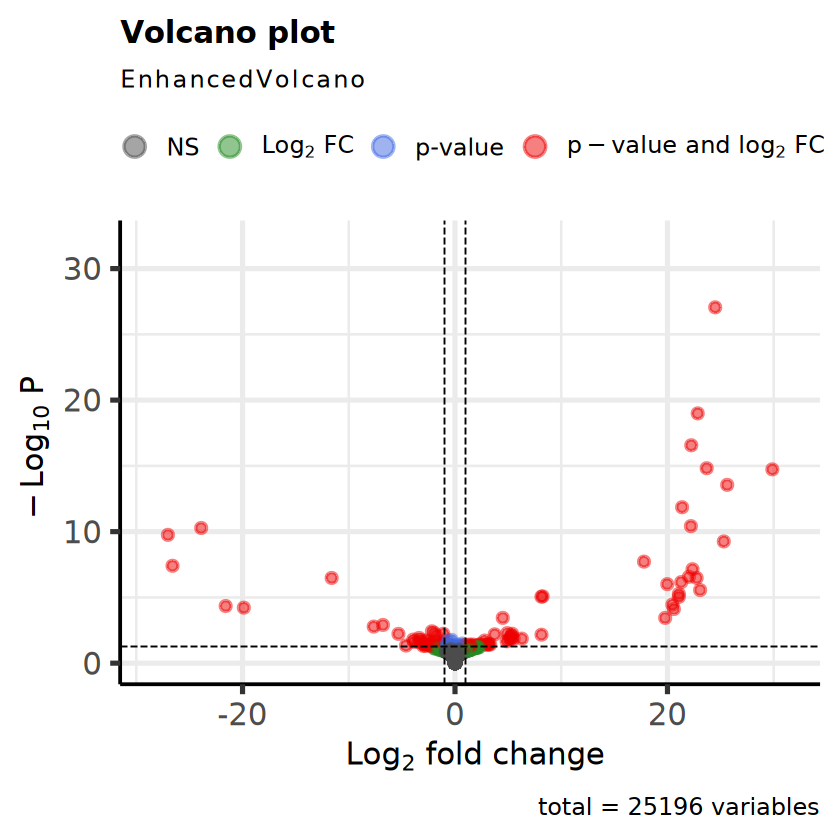

In [66]:
res.w.b <- lfcShrink(dds_filtered, 
                     contrast= c('Phase1_treatment', 'warm', 'both'), # both is the "control"
                     type = 'ashr')

summary(res.w.b)

EnhancedVolcano(res.w.b,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.w.b)

In [67]:
write.csv(res.w.b, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_both.csv')

#### hypoxic vs. both

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 133, 0.53%
LFC < 0 (down)     : 33, 0.13%
outliers [1]       : 261, 1%
low counts [2]     : 489, 1.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



log2 fold change (MMSE): Phase1_treatment hypoxic vs both 
Wald test p-value: Phase1_treatment hypoxic vs both 
DataFrame with 6 rows and 5 columns
              baseMean log2FoldChange      lfcSE     pvalue      padj
             <numeric>      <numeric>  <numeric>  <numeric> <numeric>
LOC144621260  2772.766    2.37421e-04 0.00939428 0.54121176  0.985323
LOC144621269  6797.381    3.99519e-03 0.09777042 0.39143780  0.968207
LOC111120925   191.443    5.76801e-01 1.37772077 0.00232657  0.183444
LOC144621283   932.054   -1.64962e-03 0.02636311 0.06734813  0.714580
LOC144621276 12350.889    5.07574e-05 0.00961420 0.89123594  0.998885
LOC111115920   213.339   -1.33985e-02 0.11231696 0.01551890  0.429837

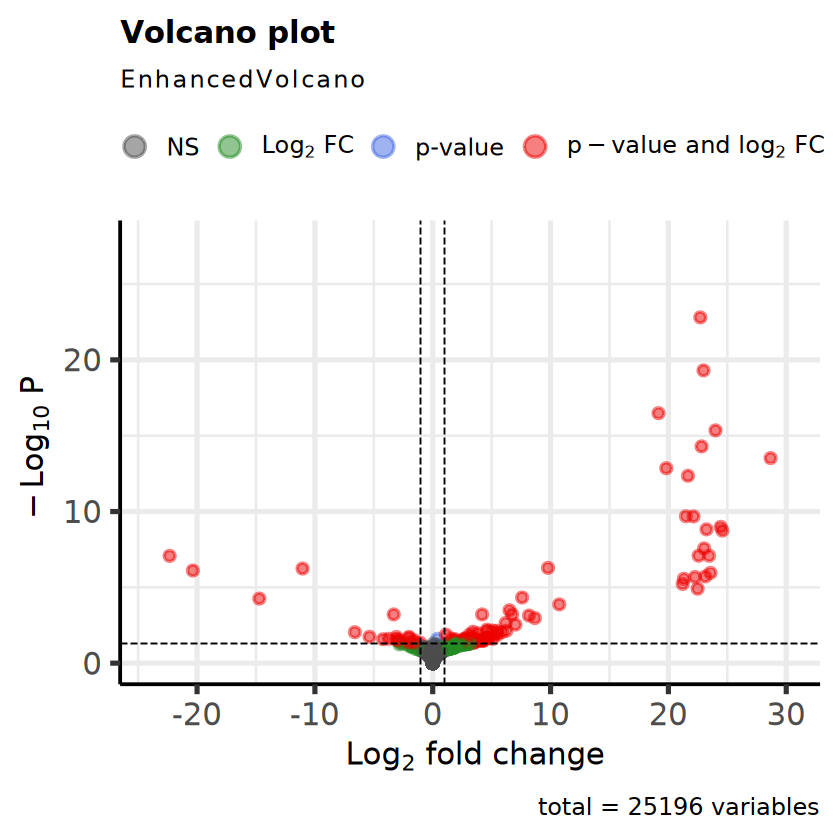

In [68]:
res.h.b <- lfcShrink(dds_filtered, 
                     contrast= c('Phase1_treatment', 'hypoxic', 'both'), # both is the "control"
                     type = 'ashr')

summary(res.h.b)

EnhancedVolcano(res.h.b,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

head(res.h.b)

In [69]:
write.csv(res.h.b, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_both.csv')

## DESeq - DO / warm treatments

nearly the same as above, but looking at the effect of hypoxia / warming (so normoxia includes C and W, hypoxia includes H and B; ambient includes C and H, warm includes W and B)

In [21]:
# phase 1 DO
p1_meta$Phase1_DO <- factor(p1_meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

In [22]:
# phase 1 tempature
p1_meta$Phase1_temp <- factor(p1_meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

In [23]:
head(p1_meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA


### phase 1 temperature
only comparing warming vs ambient (so some treatments are getting lumped together)

In [24]:
design(dds_filtered) <- ~ Phase1_temp
dds_temp <- DESeq(dds_filtered)
dds_temp

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1261 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



class: DESeqDataSet 
dim: 25196 23 
metadata(1): version
assays(6): counts mu ... replaceCounts replaceCooks
rownames(25196): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(23): baseMean baseVar ... maxCooks replace
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(11): Phase1_treatment Phase1_temp ... group replaceable

In [33]:
vsd.temp <- vst(dds_temp, blind = FALSE)
head(vsd.temp)

class: DESeqTransform 
dim: 6 23 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(23): baseMean baseVar ... replace dispFit
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(11): Phase1_treatment Phase1_temp ... group replaceable

In [36]:
write.csv(assay(vsd.temp), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_temp_vst.csv')

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 57, 0.23%
LFC < 0 (down)     : 150, 0.6%
outliers [1]       : 0, 0%
low counts [2]     : 489, 1.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


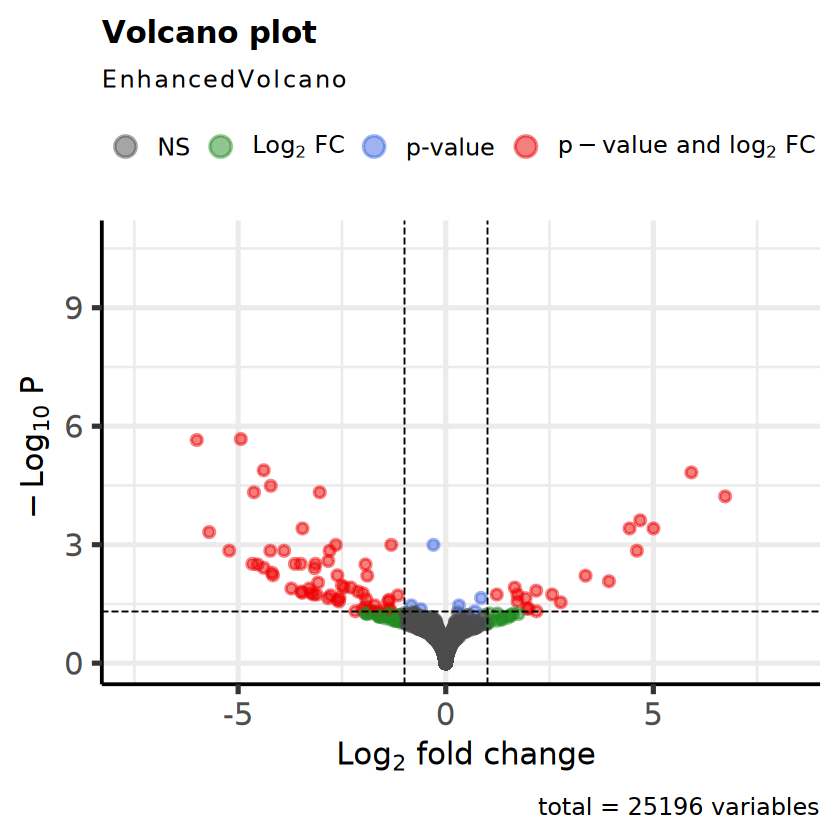

In [25]:
res.warm <- lfcShrink(dds_temp, 
                     contrast = c('Phase1_temp', 'warm', 'ambient'), 
                     type = 'ashr')

summary(res.warm)

EnhancedVolcano(res.warm,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

interesting that there's not nearly as many DEGs when you only look at ambient vs. warm treatment ...

In [26]:
write.csv(res.warm, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/warm_v_ambient.csv')

### phase 1 DO
only comparing normoxia vs hypoxia (so some treatments are getting lumped together)

In [27]:
design(dds_filtered) <- ~ Phase1_DO
dds_DO <- DESeq(dds_filtered)
dds_DO

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1170 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



class: DESeqDataSet 
dim: 25196 23 
metadata(1): version
assays(6): counts mu ... replaceCounts replaceCooks
rownames(25196): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(23): baseMean baseVar ... maxCooks replace
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(11): Phase1_treatment Phase1_temp ... group replaceable

In [37]:
vsd.DO <- vst(dds_DO, blind = FALSE)
head(vsd.DO)

class: DESeqTransform 
dim: 6 23 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(23): baseMean baseVar ... replace dispFit
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(11): Phase1_treatment Phase1_temp ... group replaceable

In [38]:
write.csv(assay(vsd.DO), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_DO_vst.csv')

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 25196 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 59, 0.23%
LFC < 0 (down)     : 30, 0.12%
outliers [1]       : 0, 0%
low counts [2]     : 1466, 5.8%
(mean count < 7)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



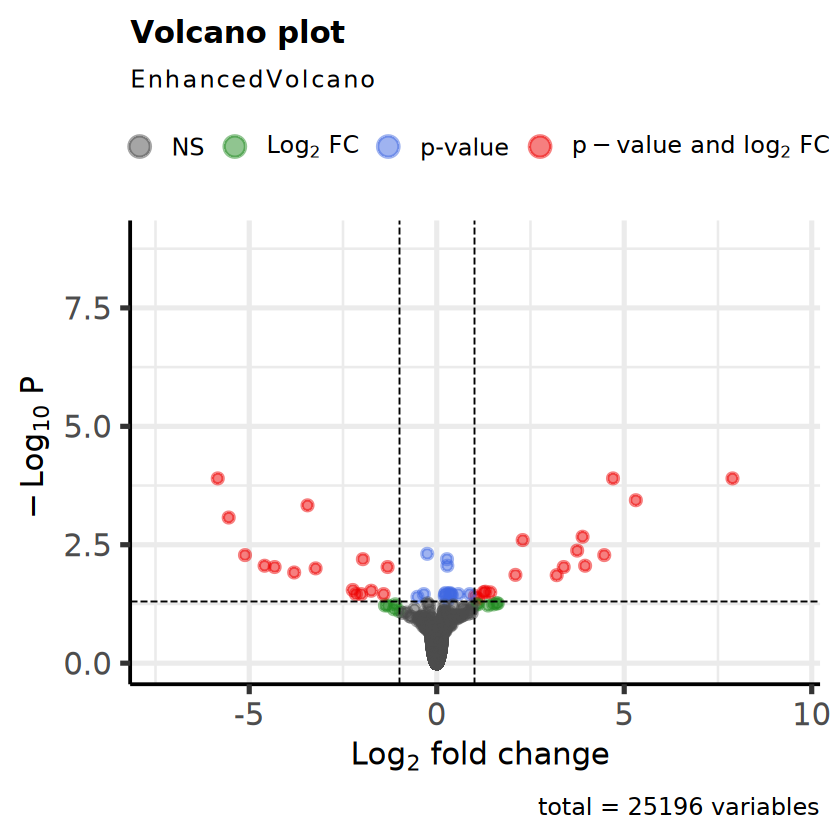

In [28]:
res.DO <- lfcShrink(dds_DO, 
                     contrast = c('Phase1_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(res.DO)

EnhancedVolcano(res.DO,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

same thing as temperature, not as many DEGs as when separating by treatment

In [29]:
write.csv(res.DO, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/hypoxic_v_normoxic.csv')

## nMDS with only significant DEGs

### DEGs from pairwise comparisons

In [43]:
# pull out all DEGs identified in any pairwise comparison
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq',
    full.names = TRUE,
    pattern = '.csv$'
    )

names(files) <- gsub('p1.', '', tools::file_path_sans_ext(basename(files)))
geneList <- lapply(files, read.csv)

# remove vst file
geneList$vst <- NULL

names(geneList)

[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
[6] "warm_v_cont"

In [44]:
# pull out DEGs in these dfs
degs <- lapply(geneList, function(df) {
      subset(df, abs(log2FoldChange) >= 1 & padj <= 0.05)
    })
head(degs$both_v_cont)

,X,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,LOC111120925,191.44305,-4.896465,1.409247,8.354541e-06,0.003583072
149,LOC111103173,15.14959,4.218014,2.190355,7.946660e-05,0.015793826
244,LOC111105159,57.17908,-5.230651,2.548703,4.742151e-05,0.010936474
386,LOC111132252,110.19476,-2.652259,2.036190,2.797628e-04,0.035210225
390,LOC111137262,591.06709,3.699058,3.002475,2.185576e-04,0.029884818
661,LOC111105069,273.29807,-3.772801,2.837354,1.914828e-04,0.027103700


In [46]:
# create list of all DEGs from the four dfs
all_degs <- degs %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(X)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 429 total DEGs
head(all_degs)

[1] 355

[1] "LOC111120925" "LOC111103173" "LOC111105159" "LOC111132252" "LOC111137262"
[6] "LOC111105069"

In [47]:
vsd_mat <- assay(vsd)

degs_vsd <- vsd_mat[rownames(vsd_mat) %in% all_degs, ]

dim(degs_vsd) # 355 total DEGs kept
head(degs_vsd)

[1] 355  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC111120925,6.162650,6.596958,6.709412,6.097391,6.365111,6.642652,8.868688,8.893482,8.281309,6.230817,⋯,8.933040,6.529973,8.449891,8.330386,6.304683,8.790027,6.259740,6.294474,5.806396,6.516750
LOC144619144,6.308952,6.368859,6.055887,6.308727,5.806396,6.401797,7.609247,6.428780,7.769140,6.464475,⋯,6.738654,6.639089,6.197893,7.039191,7.401454,6.274645,7.970384,7.725734,8.347025,6.111791
LOC111103995,11.515512,12.606930,13.741113,13.141284,12.599704,13.129737,12.114200,12.372270,11.507840,13.299032,⋯,11.481734,13.708690,12.211204,10.958682,11.691274,11.226131,10.159413,10.087799,10.798879,10.909773
LOC111103173,7.830641,5.806396,6.843724,6.265342,7.809840,6.061748,5.806396,5.806396,5.806396,6.033842,⋯,6.113570,6.303429,6.002595,6.118598,6.426185,5.806396,5.992107,6.583375,5.806396,5.806396
LOC111105159,5.806396,5.806396,6.055887,6.217233,6.005012,5.806396,8.720600,8.356112,5.806396,5.806396,⋯,6.023806,6.073008,6.002595,6.118598,6.042198,6.169733,5.806396,6.176098,6.077703,5.806396
LOC111132252,5.806396,5.806396,6.741174,5.806396,6.249125,7.550792,6.617611,6.086458,7.617086,8.336076,⋯,7.940183,6.882134,8.831051,8.947342,6.922701,7.723077,7.042304,6.561978,8.455845,6.180080


In [48]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.00000,25.93396,24.13872,27.11648,24.17125,30.73105,47.92418,47.53731,42.01555,30.35224,⋯,52.75811,27.84553,47.32770,33.42911,30.70088,45.58464,31.62493,31.63813,29.35951,29.70112
B2_Nu_O12,25.93396,0.00000,25.80842,28.60323,28.84090,28.10854,46.78424,47.03578,40.17883,28.40494,⋯,51.45389,27.49852,45.77948,29.45549,29.89678,43.47937,30.23866,32.89608,26.78917,29.42406
B4_Nu_O32,24.13872,25.80842,0.00000,23.40656,27.95165,28.19405,45.87487,45.16344,39.23405,27.68228,⋯,50.96776,21.32210,43.88229,28.53104,26.40552,43.26459,30.76637,28.98922,27.39726,27.44406
B5_Nu_O36,27.11648,28.60323,23.40656,0.00000,29.16009,30.23833,48.13383,47.70514,41.70043,31.18377,⋯,53.40101,24.90724,45.46266,32.55341,27.37621,47.33846,34.78725,31.29684,31.58036,29.20115
B6_Nu_O47,24.17125,28.84090,27.95165,29.16009,0.00000,33.01547,49.75856,49.16948,43.55862,32.96871,⋯,51.29733,28.23453,47.11279,36.99880,31.32017,47.98759,36.48692,31.34965,33.12392,32.13290
C1_Nu_W01,30.73105,28.10854,28.19405,30.23833,33.01547,0.00000,42.45894,42.90829,37.68763,22.82332,⋯,51.15497,26.08099,42.97112,26.85042,25.26375,42.95914,29.54774,28.04283,25.23732,23.36192


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor,group
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<fct>
B1_Nu_O03,-14.41434,-10.609200,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324,both
B2_Nu_O12,-12.94736,-4.938626,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462,both
B4_Nu_O32,-12.86607,-6.984026,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377,both
B5_Nu_O36,-14.39684,-10.243069,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641,both
B6_Nu_O47,-14.23107,-14.926787,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226,both
C1_Nu_W01,-10.46013,4.994836,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061,control


#### temp and DO

colored by treatment

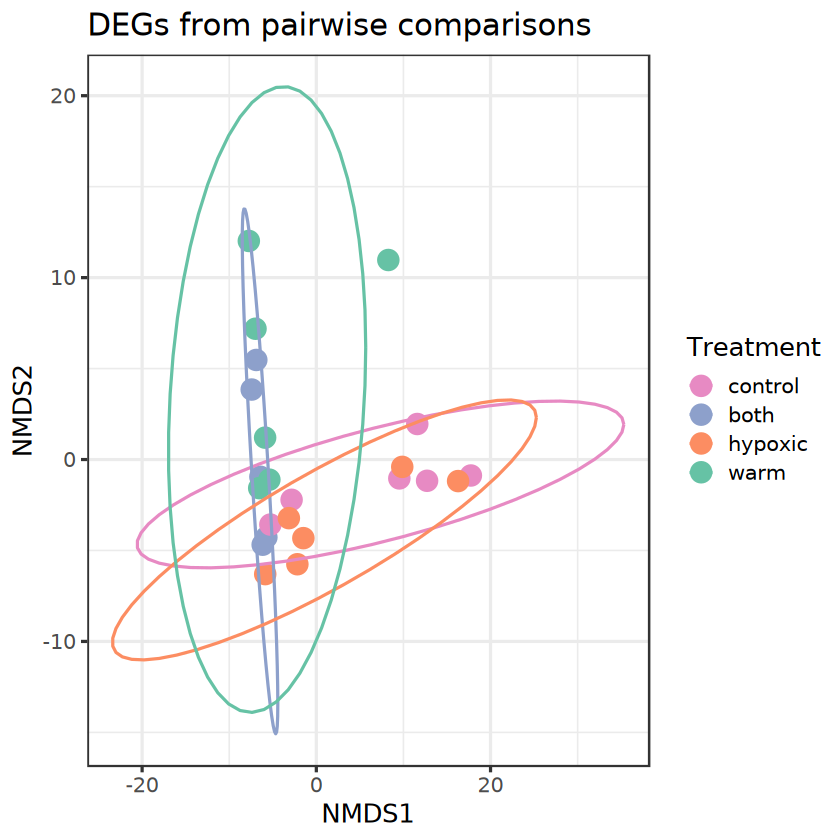

In [77]:
ggplot(mds, aes(X1, X2, col = Phase1_treatment)) +
geom_point(size = 5) +
scale_color_brewer(palette = 'Set2', direction = -1) +
stat_ellipse() + 
labs(title = 'DEGs from pairwise comparisons',
    x = 'NMDS1',
    y = 'NMDS2',
    color = 'Treatment') +
theme_bw(base_size = 15) 

colored by temp, shape by DO

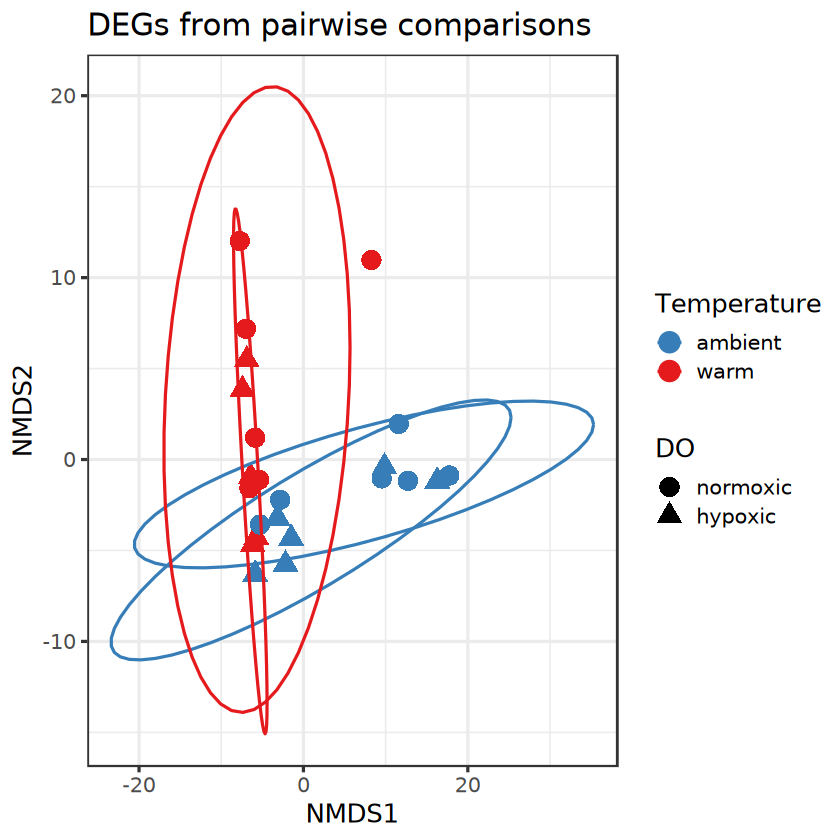

In [76]:
ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
scale_color_brewer(palette = 'Set1', direction = -1) +
stat_ellipse() + 
labs(title = 'DEGs from pairwise comparisons',
    x = 'NMDS1',
    y = 'NMDS2',
    color = 'Temperature',
    shape = 'DO') +
theme_bw(base_size = 15) 

#### just temp

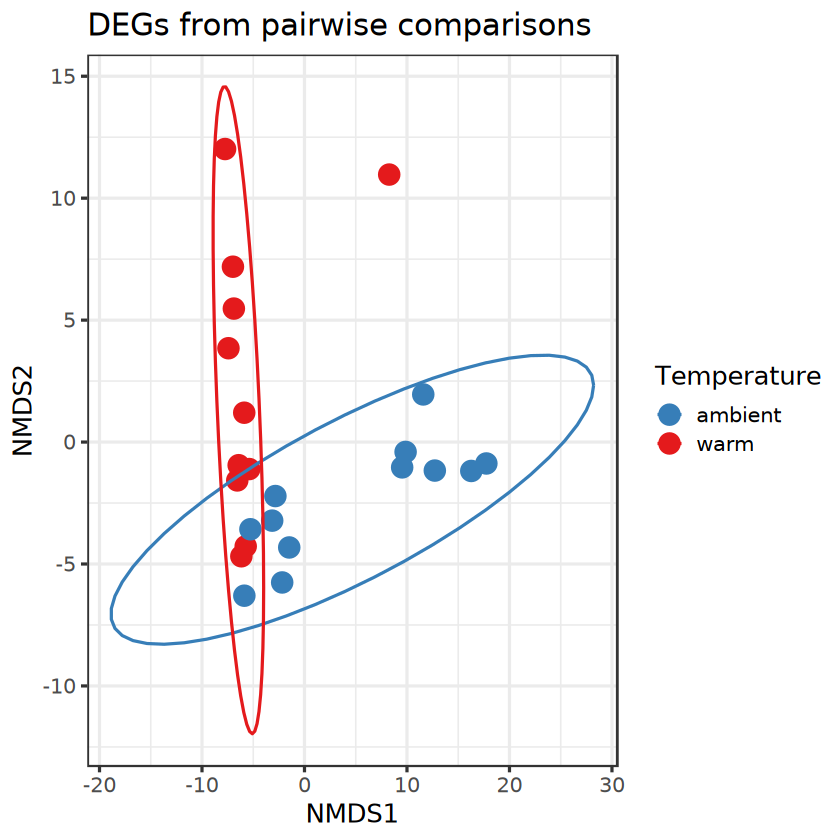

In [74]:
ggplot(mds, aes(X1, X2, col = Phase1_temp)) +
geom_point(size = 5) +
scale_color_brewer(palette = 'Set1', direction = -1) +
stat_ellipse() + 
labs(title = 'DEGs from pairwise comparisons',
    x = 'NMDS1',
    y = 'NMDS2',
    color = 'Temperature') +
theme_bw(base_size = 15) 

#### just DO

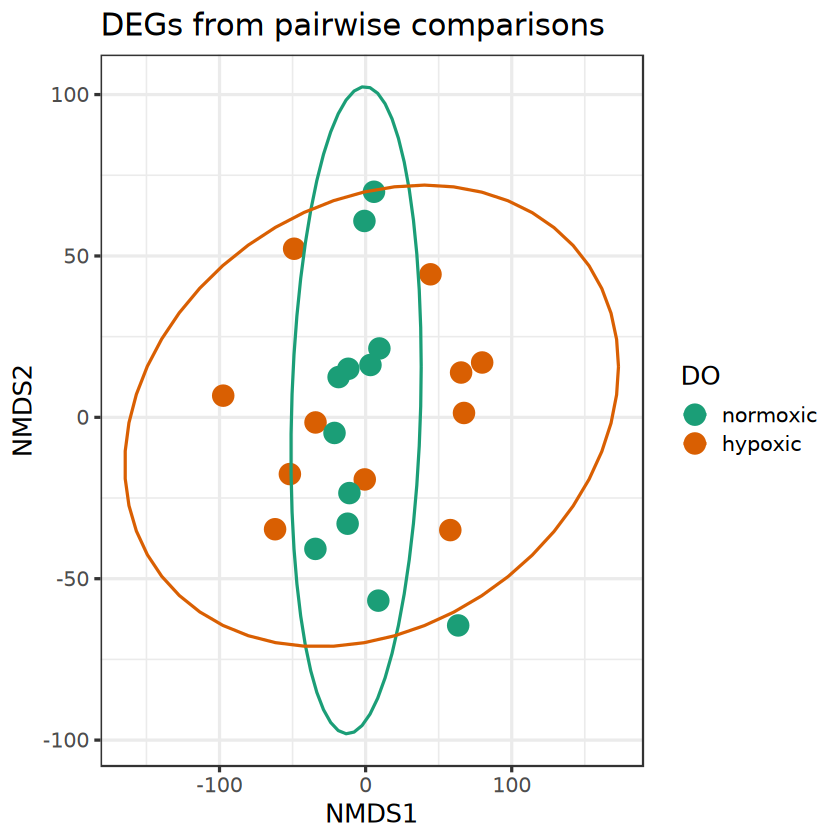

In [85]:
ggplot(mds, aes(X1, X2, col = Phase1_DO)) +
geom_point(size = 5) +
scale_color_brewer(palette = 'Dark2') +
stat_ellipse() + 
labs(title = 'DEGs from pairwise comparisons',
    x = 'NMDS1',
    y = 'NMDS2',
    color = 'DO') +
theme_bw(base_size = 15) 

In [54]:
meta3 <- meta2[meta2$Sample %in% rownames(mds),]

#### permanova

In [55]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO , data = meta3, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,2379.5146,0.15812324,4.243946,0.007
Phase1_DO,1,1271.6447,0.08450319,2.268022,0.060
Phase1_temp:Phase1_DO,1,744.3167,0.04946125,1.327514,0.181
Residual,19,10653.0055,0.70791232,NA,NA
Total,22,15048.4815,1.00000000,NA,NA


when we limit the NMDS to only include DEGs from all comparisons, we see a significant effect of temperature on gene expression profiles. This to me signals that temperature is the most influential on gene expression patterns.

### DEGs from isolated treatments

In [60]:
# pull out DEGs identified 

# read in dfs
do <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/isolated_treatments/hypoxic_v_normoxic.csv')
temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/isolated_treatments/warm_v_ambient.csv')

# merge
degs <- rbind(do, temp) %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1) 

deg_list <- unique(degs$X)
length(deg_list) # 103 total DEGs
head(deg_list)

[1] 103

[1] "LOC111105442" "LOC144622706" "LOC111105472" "LOC144625532" "LOC111101639"
[6] "LOC144626224"

In [61]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% deg_list,]

dim(degs_vsd) # 112 total DEGs kept
head(degs_vsd)

[1] 103  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC111105159,5.806396,5.806396,6.055887,6.217233,6.005012,5.806396,8.720600,8.356112,5.806396,5.806396,⋯,6.023806,6.073008,6.002595,6.118598,6.042198,6.169733,5.806396,6.176098,6.077703,5.806396
LOC111103328,5.984862,6.182683,9.856915,6.217233,5.806396,7.383689,9.554748,9.851870,9.395732,8.611180,⋯,14.644463,7.923472,9.111231,9.119435,7.171302,10.012749,6.295731,7.718947,6.077703,6.111791
LOC111105442,6.614159,8.712068,6.786637,6.667999,11.829358,6.894900,6.839073,6.487149,5.976392,6.312902,⋯,11.102436,6.399227,6.083650,7.231536,6.139500,6.016538,6.518885,6.126785,6.138435,6.756670
LOC144622706,6.513613,6.733735,10.389196,6.776500,9.837335,6.061748,6.203840,6.458662,6.576682,6.033842,⋯,8.477866,9.585216,9.256512,5.806396,6.468266,6.556273,5.806396,6.921079,6.189521,6.180080
LOC111105472,11.951075,6.715601,6.111769,6.217233,11.979641,6.696209,5.806396,6.995159,6.046668,6.312902,⋯,11.301253,6.659081,5.806396,6.247064,6.748465,7.524536,6.127615,6.717943,6.466175,5.806396
LOC144625532,6.058625,5.806396,5.982923,5.806396,8.321544,5.806396,6.150863,6.201847,6.046668,5.967308,⋯,9.010821,6.227054,5.806396,6.387673,5.973226,6.169733,5.806396,6.258573,6.077703,6.022544


In [62]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.00000,13.17006,20.65954,18.08430,16.05238,19.09802,25.15203,25.18078,22.12417,18.02040,⋯,28.29051,19.08330,23.43159,19.44373,16.62845,22.31445,15.56499,16.77230,14.52158,15.49890
B2_Nu_O12,13.17006,0.00000,18.90391,17.49962,17.12143,19.52399,26.33546,25.18712,22.35970,18.17914,⋯,28.32709,18.48829,25.16163,18.17642,15.69961,23.42110,17.38286,17.39607,13.83119,17.33509
B4_Nu_O32,20.65954,18.90391,0.00000,18.97589,22.43697,17.99581,26.67930,24.85832,23.45913,20.35593,⋯,28.12691,10.89056,25.26473,18.25909,17.83142,24.07861,21.96579,14.86541,19.92848,19.51797
B5_Nu_O36,18.08430,17.49962,18.97589,0.00000,18.76779,19.51663,24.36305,22.83863,20.12449,17.88718,⋯,29.35181,17.35269,22.56285,17.96848,12.74654,25.49770,21.32489,14.26156,17.06295,16.49738
B6_Nu_O47,16.05238,17.12143,22.43697,18.76779,0.00000,19.26545,27.60800,25.86924,23.59164,20.35129,⋯,26.97030,21.24401,25.23135,21.35685,16.96649,26.46011,22.62111,18.02371,18.85422,18.87647
C1_Nu_W01,19.09802,19.52399,17.99581,19.51663,19.26545,0.00000,24.33722,24.34019,20.61122,15.91721,⋯,27.41687,15.31510,24.78876,18.08602,17.27088,24.44568,20.15641,15.25495,18.77948,17.39554


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor,group
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<fct>
B1_Nu_O03,-6.890722,5.4733099,both,warm,hypoxic,1,NA,NA,NA,NA,1.1662324,both
B2_Nu_O12,-7.418627,3.8473425,both,warm,hypoxic,2,NA,NA,NA,NA,1.0447462,both
B4_Nu_O32,-6.160249,-4.6829904,both,warm,hypoxic,4,NA,NA,NA,NA,1.1920377,both
B5_Nu_O36,-5.735506,-4.2743526,both,warm,hypoxic,5,NA,NA,NA,NA,0.8754641,both
B6_Nu_O47,-6.422207,-0.9491942,both,warm,hypoxic,6,NA,NA,NA,NA,0.9413226,both
C1_Nu_W01,-5.275534,-3.5751282,control,ambient,normoxic,1,NA,NA,NA,NA,1.1378061,control


#### temp and DO
colored by treatment

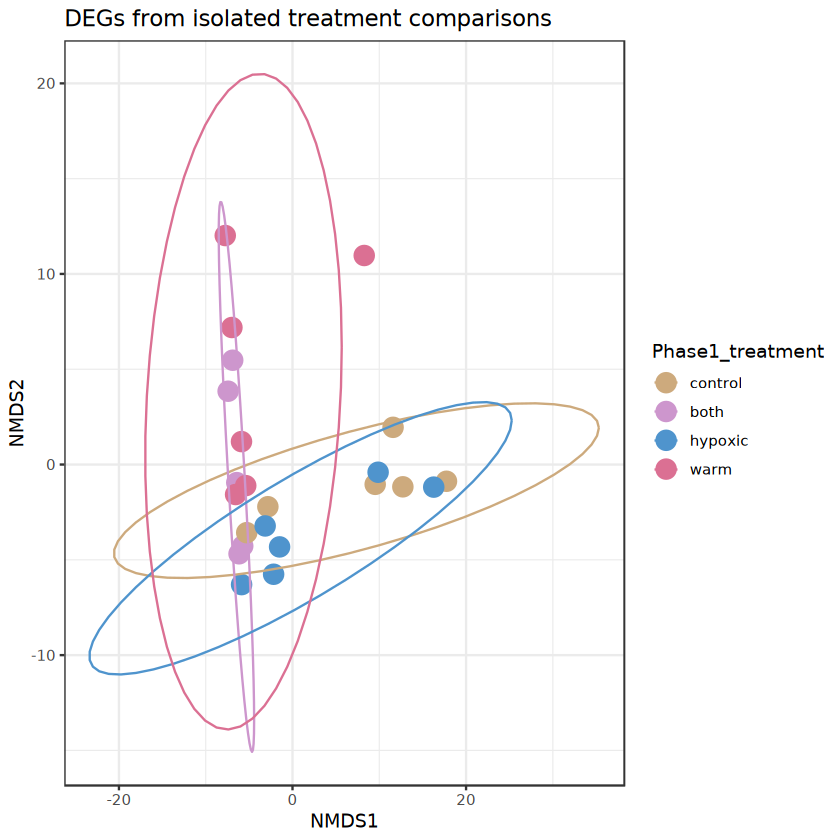

In [66]:
ggplot(mds, aes(X1, X2, col = Phase1_treatment)) +
geom_point(size = 5) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
stat_ellipse() + 
labs(title = 'DEGs from isolated treatment comparisons',
    x = 'NMDS1',
    y = 'NMDS2') +
theme_bw()

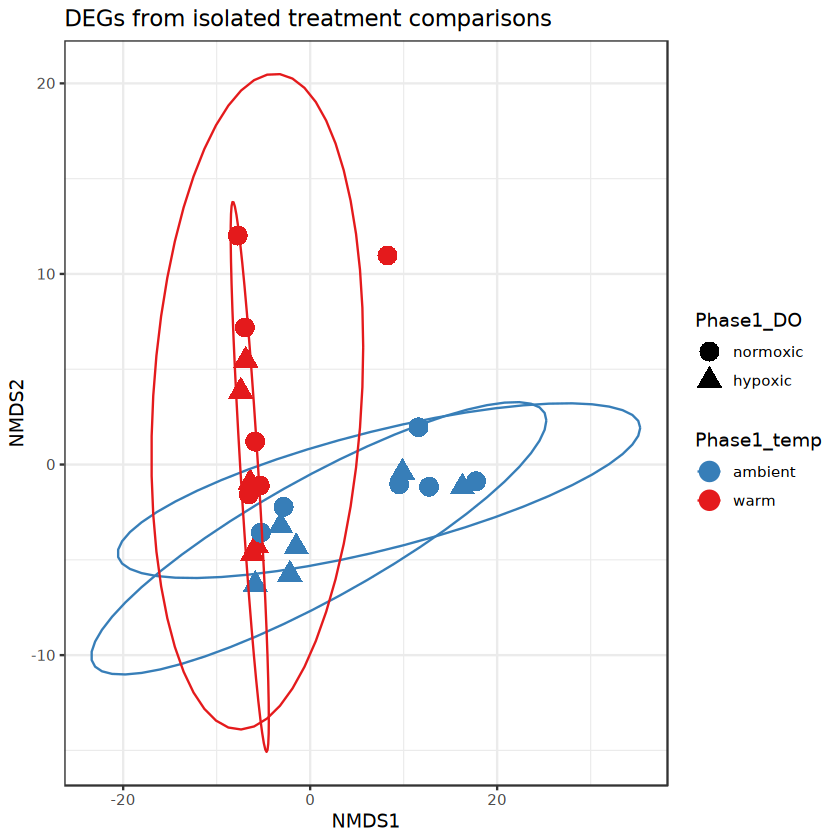

In [65]:
ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
scale_color_brewer(palette = 'Set1', direction = -1) +
stat_ellipse() + 
labs(title = 'DEGs from isolated treatment comparisons',
    x = 'NMDS1',
    y = 'NMDS2') +
theme_bw()

#### just temp

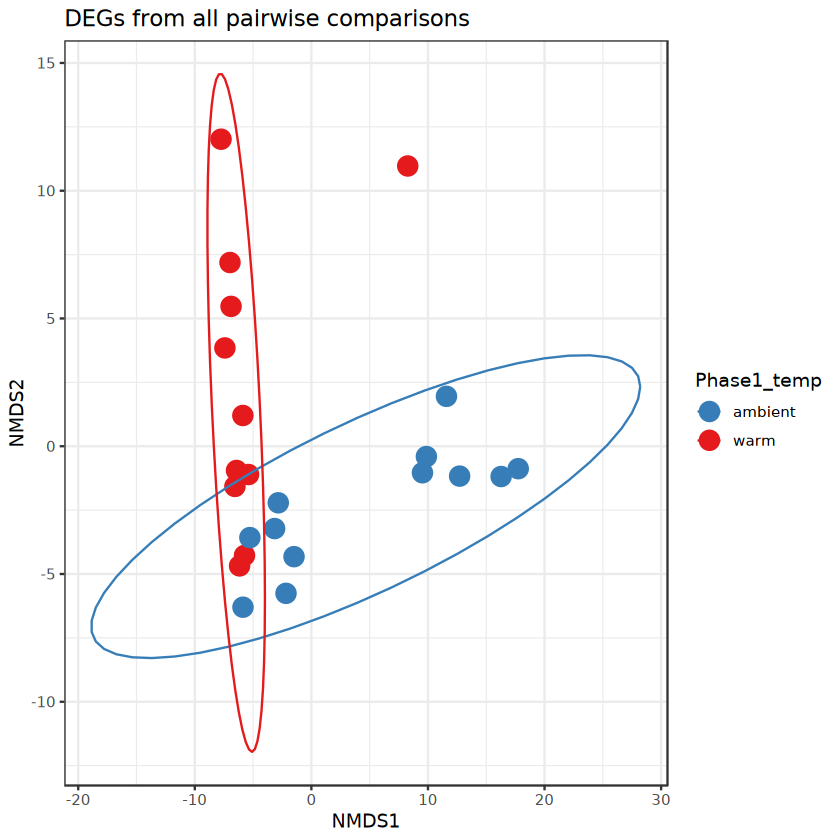

In [67]:
ggplot(mds, aes(X1, X2, col = Phase1_temp)) +
geom_point(size = 5) +
scale_color_brewer(palette = 'Set1', direction = -1) +
stat_ellipse() + 
labs(title = 'DEGs from all pairwise comparisons',
    x = 'NMDS1',
    y = 'NMDS2') +
theme_bw()

#### just DO

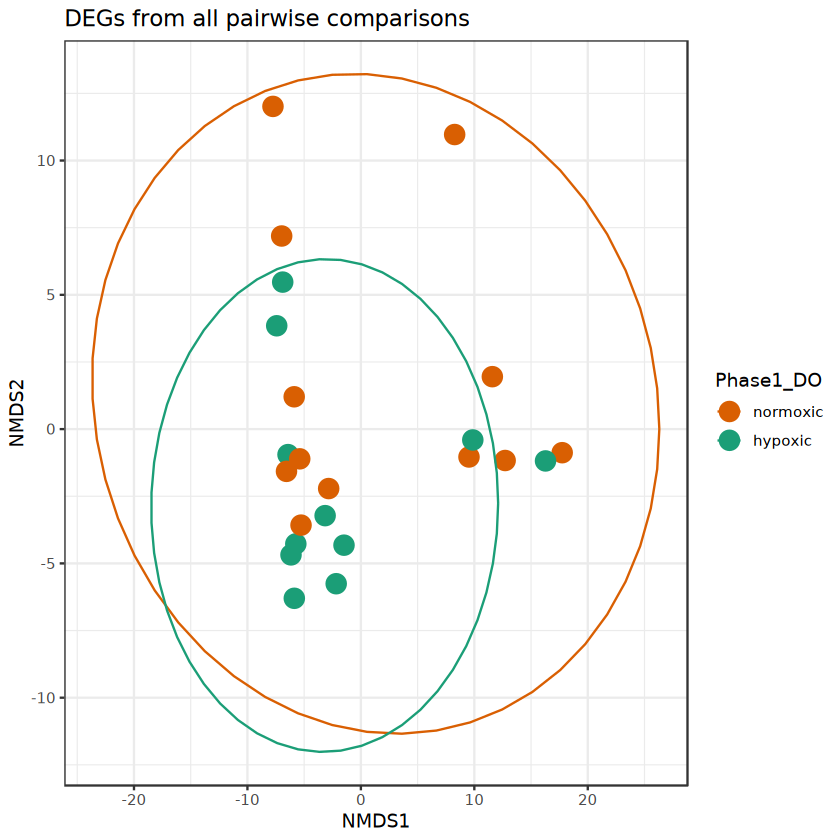

In [70]:
ggplot(mds, aes(X1, X2, col = Phase1_DO)) +
geom_point(size = 5) +
scale_color_brewer(palette = 'Dark2', direction = -1) +
stat_ellipse() + 
labs(title = 'DEGs from all pairwise comparisons',
    x = 'NMDS1',
    y = 'NMDS2') +
theme_bw()

#### permanova

In [71]:
meta3 <- meta2[meta2$Sample %in% rownames(mds),]

In [72]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO , data = meta3, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,777.6290,0.15861822,4.0529784,0.001
Phase1_DO,1,348.4561,0.07107693,1.8161422,0.060
Phase1_temp:Phase1_DO,1,130.9799,0.02671686,0.6826634,0.767
Residual,19,3645.4553,0.74358800,NA,NA
Total,22,4902.5204,1.00000000,NA,NA


similar to when we use the DEGs from all pairwise comparisons, a significant effect of phase 1 temperature on gene expression profiles emerges